# PaSCient: supervised sample-level representations

[PaSCient](https://github.com/genentech/pascient) ([Rauer et al., 2024](https://arxiv.org/abs/2404.14413)) is a supervised deep learning method that learns patient-level representations from single-cell data. It uses a gene-to-cell encoder, attention-based cell-to-patient aggregation, and a patient encoder to produce fixed-size sample embeddings.

This notebook demonstrates how to use PaSCient through `patpy` on the COMBAT dataset.

## Setup

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.14.0'

## Load and prepare data

We use the COMBAT dataset ([COMBAT Consortium, 2022](https://doi.org/10.1016/j.cell.2022.01.012)), available on [Kaggle](https://www.kaggle.com/datasets/vshitov/combat-covid-19-single-cell).

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_2416752/1289119485.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)


binary_condition
1    524530
0     87204
Name: count, dtype: int64

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

**Important:** PaSCient expects gene expression as input. You can either provide raw counts via the `layer` parameter (with `normalize=True`, the default, which applies log-normalization automatically), or provide already log-normalized data in `adata.X` (with `normalize=False`). Providing the correct expression input is critical for good performance.

In [10]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    layer="X_raw_counts",
    normalize=True,
    n_cells=1500,
    batch_size=16,
    n_epochs=4,
    device="cuda",
)

In [11]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 10. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=4` reached.


## Sample representations

Extract sample-level embeddings and evaluate using the KNN prediction score.

In [12]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,-0.033526,-0.020915,0.899917,0.221825,0.447788,-0.044548,1.022697,-0.095359,-0.048951,0.183261,...,0.119305,-0.089081,0.479033,-0.145253,0.661910,-0.121614,0.570083,0.178066,-0.046186,-0.076446
S00112-Ja003E-PBCa,-0.031918,-0.013391,0.840995,0.217706,0.433124,-0.039012,0.964026,-0.100688,-0.040779,0.182353,...,0.181499,-0.080453,0.493424,-0.145380,0.639670,-0.114061,0.573245,0.184026,-0.043882,-0.077578
S00005-Ja005E-PBCa,-0.028173,-0.022318,0.855369,0.238028,0.454850,-0.030748,0.986854,-0.094311,-0.044846,0.186738,...,0.169381,-0.087818,0.486598,-0.152397,0.666587,-0.122966,0.570000,0.175243,-0.047978,-0.080192
S00061-Ja003E-PBCa,-0.032769,-0.022477,0.963919,0.216226,0.488774,-0.043007,1.090575,-0.106707,-0.048494,0.186367,...,0.151084,-0.092954,0.533826,-0.162442,0.741820,-0.128635,0.621928,0.202500,-0.057236,-0.080993
S00056-Ja003E-PBCa,-0.033063,-0.020424,0.874535,0.235536,0.460536,-0.035814,1.009767,-0.106149,-0.043205,0.193505,...,0.202493,-0.084582,0.519801,-0.148871,0.697424,-0.117586,0.593837,0.186102,-0.047944,-0.078118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,-0.039353,-0.014672,0.796470,0.210577,0.426012,-0.025590,0.886550,-0.087851,-0.033527,0.137416,...,0.128042,-0.081427,0.471687,-0.135577,0.578203,-0.111099,0.541653,0.160471,-0.044496,-0.070159
S00072-Ja001E-PBCa,-0.035379,-0.005569,0.682273,0.237289,0.377216,-0.027414,0.798358,-0.081371,-0.033831,0.116259,...,0.138813,-0.067970,0.452494,-0.116547,0.510274,-0.103189,0.432631,0.094448,-0.051955,-0.055053
S00065-Ja003E-PBCa,-0.040126,-0.019023,0.819954,0.230882,0.434063,-0.024228,0.969430,-0.093894,-0.041002,0.204300,...,0.156465,-0.086891,0.520990,-0.146861,0.616371,-0.117547,0.566917,0.159023,-0.049723,-0.067695
S00048-Ja003E-PBCa,-0.029269,-0.011566,0.853688,0.196550,0.455592,-0.036276,0.959479,-0.092824,-0.049522,0.183627,...,0.169884,-0.084960,0.499955,-0.144140,0.670303,-0.114407,0.555169,0.169309,-0.046821,-0.080087


In [13]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': 0.8979797979797981,
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


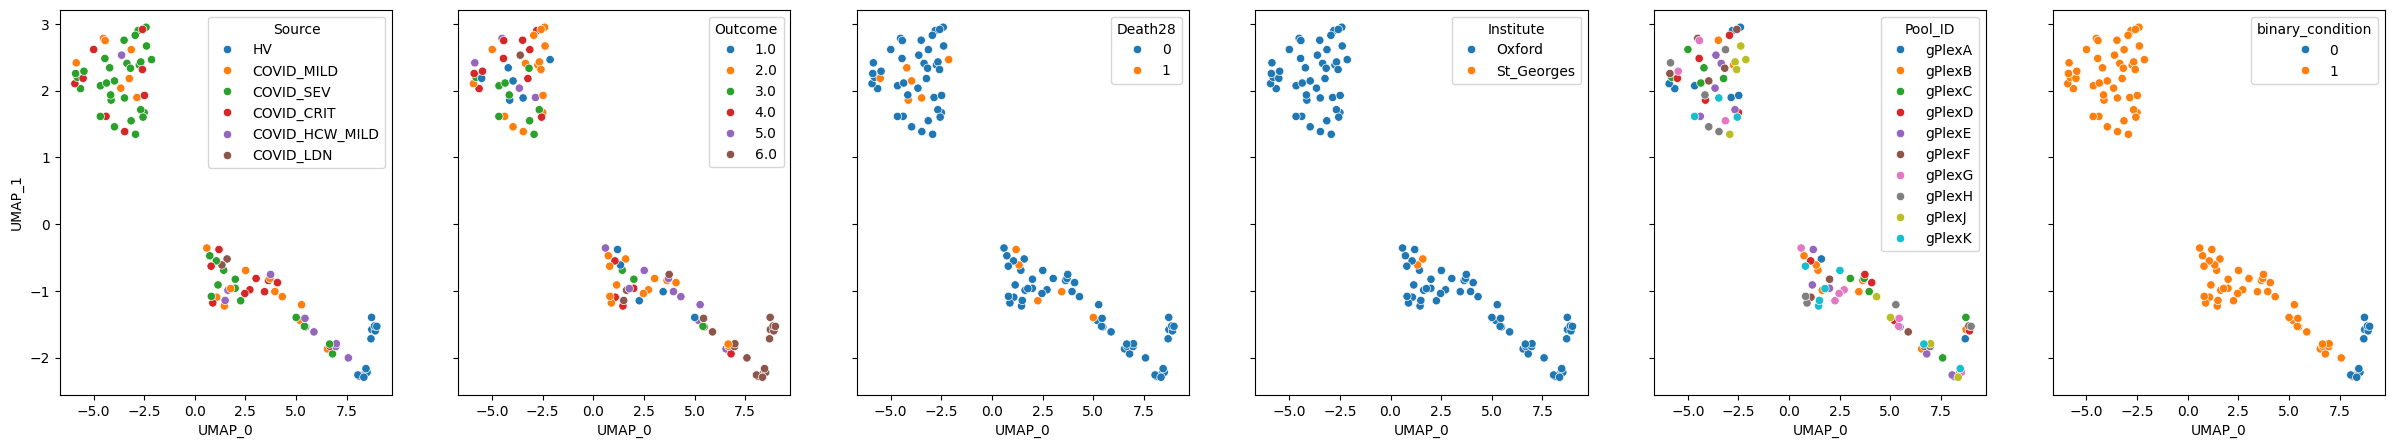

In [14]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

## Binary prediction

Fine-tune a linear probe on top of the learned representations and predict.

In [15]:
pascient.fine_tune("binary_condition", tasks="classification")

In [16]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.003808,0.996192,1
S00112-Ja003E-PBCa,0.006677,0.993323,1
S00005-Ja005E-PBCa,0.005429,0.994571,1
S00061-Ja003E-PBCa,0.000478,0.999522,1
S00056-Ja003E-PBCa,0.002444,0.997556,1
...,...,...,...
S00076-Ja001E-PBCa,0.033936,0.966064,1
S00072-Ja001E-PBCa,0.387013,0.612987,1
S00065-Ja003E-PBCa,0.012914,0.987086,1
S00048-Ja003E-PBCa,0.006244,0.993756,1


In [17]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       1.00      0.97      0.98        91

    accuracy                           0.97       101
   macro avg       0.88      0.98      0.93       101
weighted avg       0.98      0.97      0.97       101



## Multiclass prediction

We can also fine-tune for the multiclass `Source` label.

In [18]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [19]:
pascient.fine_tune("Source", tasks="classification")

In [20]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.246314,0.053146,0.190818,0.186646,0.322152,0.000924,COVID_SEV
S00112-Ja003E-PBCa,0.238390,0.083342,0.196449,0.217562,0.262445,0.001812,COVID_SEV
S00005-Ja005E-PBCa,0.258500,0.067422,0.204170,0.190783,0.277725,0.001400,COVID_SEV
S00061-Ja003E-PBCa,0.232344,0.016334,0.131405,0.166193,0.453651,0.000072,COVID_SEV
S00056-Ja003E-PBCa,0.260723,0.045837,0.198424,0.180396,0.314080,0.000540,COVID_SEV
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.197445,0.213798,0.178613,0.232494,0.166087,0.011562,COVID_MILD
S00072-Ja001E-PBCa,0.105942,0.375067,0.126400,0.146024,0.052434,0.194133,COVID_HCW_MILD
S00065-Ja003E-PBCa,0.254653,0.105990,0.201136,0.201018,0.233278,0.003925,COVID_CRIT
S00048-Ja003E-PBCa,0.254004,0.072814,0.181348,0.203009,0.287157,0.001668,COVID_SEV


In [21]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.60      0.33      0.43        18
COVID_HCW_MILD       0.47      0.67      0.55        12
     COVID_LDN       0.50      1.00      0.67         2
    COVID_MILD       0.60      0.33      0.43        18
     COVID_SEV       0.63      0.76      0.69        41
            HV       0.91      1.00      0.95        10

      accuracy                           0.62       101
     macro avg       0.62      0.68      0.62       101
  weighted avg       0.63      0.62      0.61       101



## Sample and cell importance

PaSCient provides interpretability through importance scores at both the sample and cell level.

**Sample importance** is the L2 norm of the sample embedding — samples with larger norms contribute more to the model's predictions.

In [22]:
pascient_sample_importance = pascient.get_sample_importance()
pascient_sample_importance.head()

,average_importance,binary_condition_importance,Source_importance
S00109-Ja001E-PBCa,8.661301,8.661301,8.661301
S00112-Ja003E-PBCa,8.460336,8.460336,8.460336
S00005-Ja005E-PBCa,8.537621,8.537621,8.537621
S00061-Ja003E-PBCa,9.374258,9.374258,9.374258
S00056-Ja003E-PBCa,8.813501,8.813501,8.813501


### Cell importance: Integrated Gradients vs. cosine similarity

PaSCient supports two methods for computing cell importance:

1. **Integrated Gradients (IG)** — the approach from the PaSCient paper ([De Brouwer et al., 2024](https://arxiv.org/abs/2404.14413)). It uses [captum](https://captum.ai/) to attribute the model's prediction to each cell by accumulating gradients along a path from a zero baseline. The per-cell score is the L2 norm of the per-gene IG attribution vector. Requires the `captum` package.

2. **Cosine similarity** — a lightweight proxy that measures the cosine similarity between each cell's embedding and the patient-level embedding. No extra dependencies needed.

Let's compute both and compare.

In [23]:
# Integrated Gradients (default when captum is installed)
ig_scores = pascient._cell_importance_ig(target=0)

# Cosine similarity fallback
cosine_scores = pascient._cell_importance_cosine()

print(f"IG scores: min={ig_scores.min():.4f}, max={ig_scores.max():.4f}, mean={ig_scores.mean():.4f}")
print(f"Cosine scores: min={cosine_scores.min():.4f}, max={cosine_scores.max():.4f}, mean={cosine_scores.mean():.4f}")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:2095: UserWarning: Using data from adata.layers['X_raw_counts']
  cell_data = self._get_data()[cell_mask]


IG scores: min=0.0000, max=0.0057, mean=0.0000
Cosine scores: min=0.0000, max=0.2193, mean=0.0269


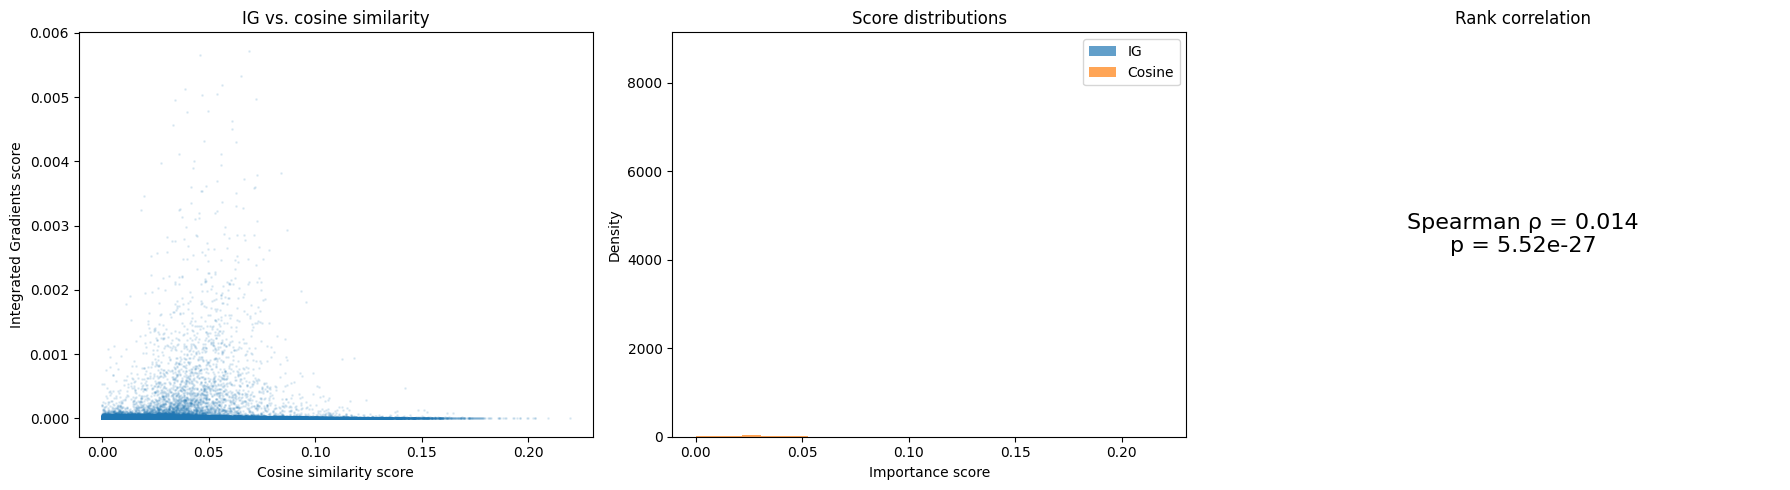

In [24]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter: IG vs cosine
axes[0].scatter(cosine_scores, ig_scores, alpha=0.1, s=1)
axes[0].set_xlabel("Cosine similarity score")
axes[0].set_ylabel("Integrated Gradients score")
axes[0].set_title("IG vs. cosine similarity")

# Distribution comparison
axes[1].hist(ig_scores, bins=50, alpha=0.7, label="IG", density=True)
axes[1].hist(cosine_scores, bins=50, alpha=0.7, label="Cosine", density=True)
axes[1].set_xlabel("Importance score")
axes[1].set_ylabel("Density")
axes[1].set_title("Score distributions")
axes[1].legend()

# Rank correlation
from scipy.stats import spearmanr
rho, pval = spearmanr(ig_scores, cosine_scores)
axes[2].text(0.5, 0.5, f"Spearman ρ = {rho:.3f}\np = {pval:.2e}",
             ha="center", va="center", fontsize=16, transform=axes[2].transAxes)
axes[2].set_title("Rank correlation")
axes[2].axis("off")

plt.tight_layout()
plt.show()

### Cell importance by disease severity

Visualize the distribution of IG-based cell importance scores across disease severity groups and cell types.

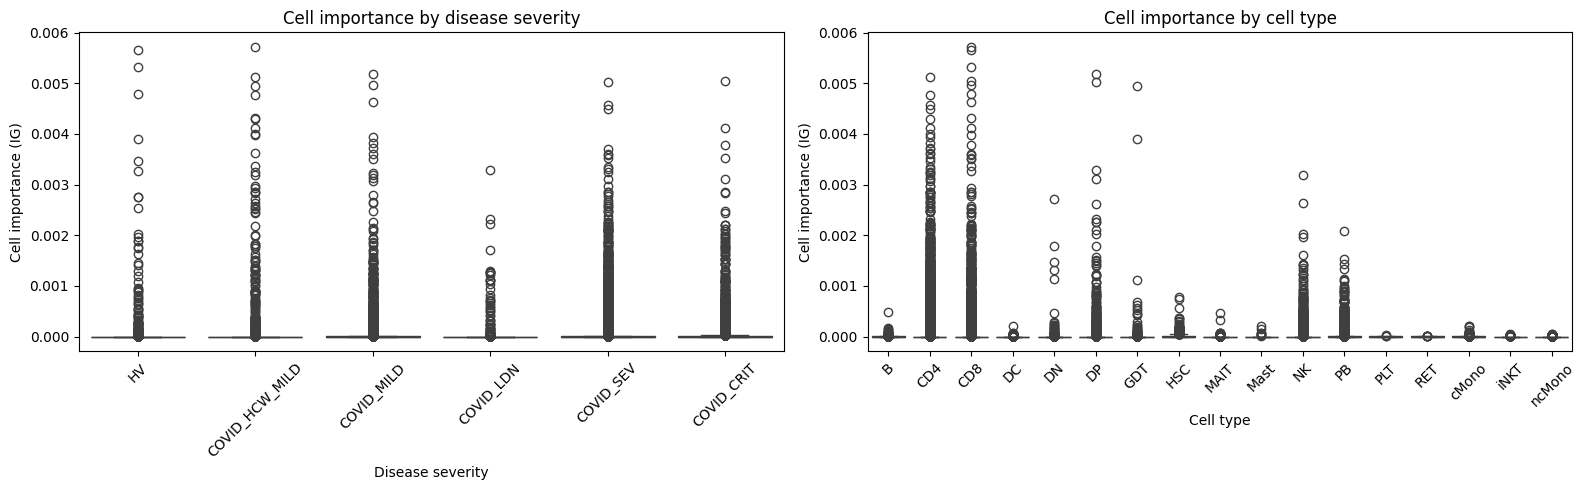

In [25]:
# Use IG scores for visualization
cell_imp_df = pd.DataFrame({
    "ig_importance": ig_scores,
    "cosine_importance": cosine_scores,
    "Source": adata.obs["Source"].values,
    "cell_type": adata.obs[cell_type_key].values,
}, index=adata.obs_names)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

severity_order = ["HV", "COVID_HCW_MILD", "COVID_MILD", "COVID_LDN", "COVID_SEV", "COVID_CRIT"]
sns.boxplot(
    data=cell_imp_df,
    x="Source",
    y="ig_importance",
    order=severity_order,
    ax=axes[0],
)
axes[0].set_xlabel("Disease severity")
axes[0].set_ylabel("Cell importance (IG)")
axes[0].set_title("Cell importance by disease severity")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(
    data=cell_imp_df,
    x="cell_type",
    y="ig_importance",
    ax=axes[1],
)
axes[1].set_xlabel("Cell type")
axes[1].set_ylabel("Cell importance (IG)")
axes[1].set_title("Cell importance by cell type")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## Recompute distances and visualize after fine-tuning

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


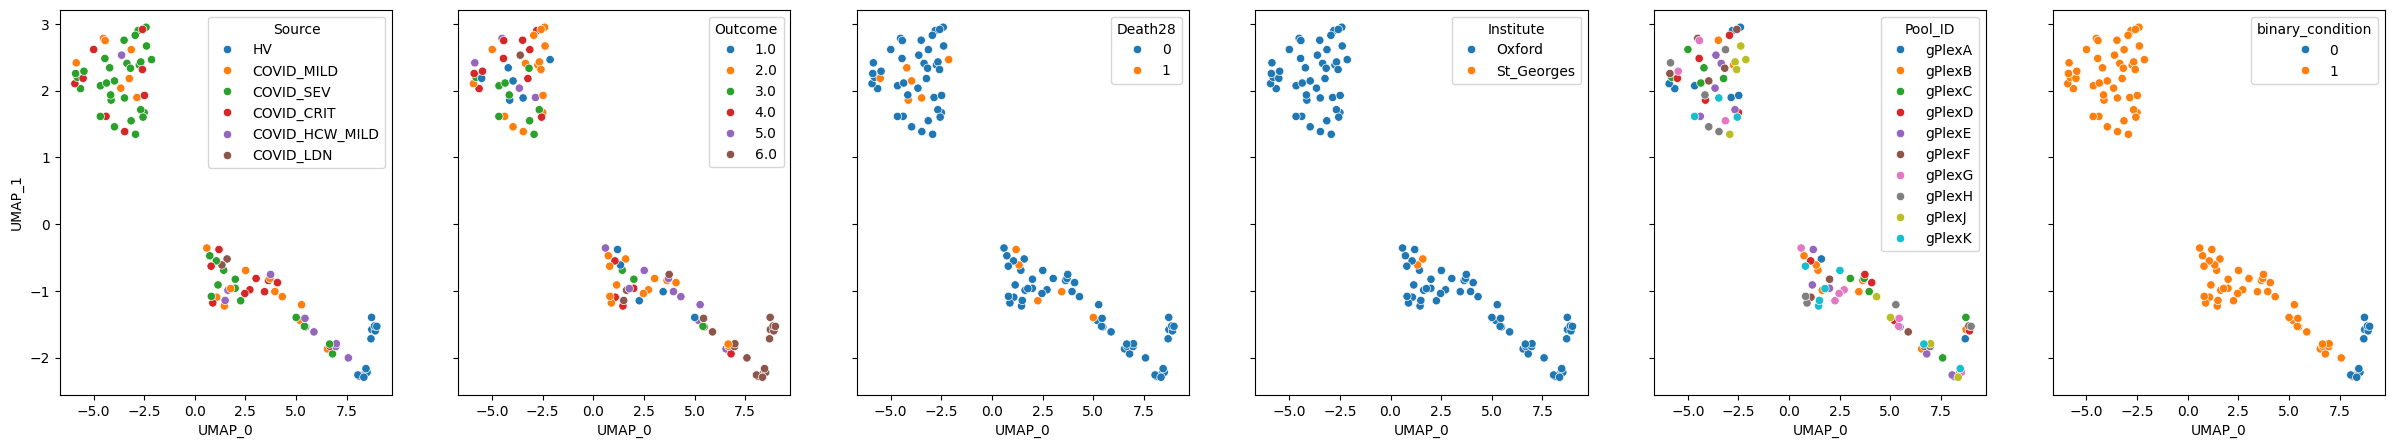

In [26]:
pascient.calculate_distance_matrix()
pascient.embed("UMAP")
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

In this tutorial you learned how to train PaSCient from scratch, extract sample representations, evaluate them, make binary and multiclass predictions, and compute importance scores with `patpy`.